In [ ]:
# 03 - Model Training

This notebook compares supervised machine-learning models for
classification of Parkinson's disease versus healthy controls using
smartwatch-derived movement features.

Models:
- Logistic Regression
- Support Vector Machine
- Random Forest

To prevent subject-level data leakage, all recordings from an individual
participant are kept entirely within either the training or test set.

In [77]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
PROJECT_DIR = Path.cwd().parent

FEATURE_PATH = (
    PROJECT_DIR
    / "outputs"
    / "tables"
    / "pads_recording_features.csv"
)

df = pd.read_csv(
    FEATURE_PATH,
    dtype={"subject_id": str}
)

df["subject_id"] = df["subject_id"].str.zfill(3)

print(df.shape)
display(df.head())

(7810, 101)


,subject_id,task,wrist,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_median,Accelerometer_X_min,Accelerometer_X_max,Accelerometer_X_range,Accelerometer_X_rms,...,Gyro_Magnitude_max,Gyro_Magnitude_range,Gyro_Magnitude_rms,Gyro_Magnitude_iqr,Gyro_Magnitude_skewness,Gyro_Magnitude_kurtosis,Gyro_Magnitude_dominant_frequency,Gyro_Magnitude_spectral_energy,condition,target
0,001,Relaxed,LeftWrist,-0.002355,0.004685,-0.002421,-0.023458,0.131153,0.154611,0.005243,...,0.832345,0.831603,0.027746,0.009336,24.241803,732.420030,0.292969,0.012154,Healthy,0
1,001,Relaxed,RightWrist,-0.000341,0.003976,-0.000393,-0.018510,0.126071,0.144581,0.003990,...,0.888577,0.888003,0.027177,0.007645,26.946439,869.019946,0.244141,0.012470,Healthy,0
2,001,RelaxedTask,LeftWrist,-0.001586,0.006423,-0.001676,-0.038445,0.112102,0.150547,0.006616,...,0.600682,0.599432,0.060239,0.040146,4.204530,36.679898,0.048828,0.033624,Healthy,0
3,001,RelaxedTask,RightWrist,0.000329,0.005473,0.000204,-0.022960,0.166025,0.188985,0.005483,...,0.908047,0.906745,0.035954,0.016057,19.766278,570.043186,0.048828,0.015654,Healthy,0
4,001,StretchHold,LeftWrist,-0.001594,0.005821,-0.001792,-0.033946,0.119273,0.153219,0.006035,...,0.838530,0.835350,0.039254,0.012123,19.827422,463.195996,0.292969,0.010282,Healthy,0


In [5]:
metadata_columns = [
    "subject_id",
    "task",
    "wrist",
    "condition",
    "target"
]

feature_columns = [
    col for col in df.columns
    if col not in metadata_columns
]

X = df[feature_columns]
y = df["target"]
groups = df["subject_id"]

print("X shape:", X.shape)
print("Number of features:", len(feature_columns))
print("Participants:", groups.nunique())

X shape: (7810, 96)
Number of features: 96
Participants: 355


In [7]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

In [9]:
train_subjects = set(groups_train)
test_subjects = set(groups_test)

overlap = train_subjects.intersection(test_subjects)

print("Training participants:", len(train_subjects))
print("Test participants:", len(test_subjects))
print("Participant overlap:", len(overlap))

print("\nTraining recordings:", len(X_train))
print("Test recordings:", len(X_test))

Training participants: 284
Test participants: 71
Participant overlap: 0

Training recordings: 6248
Test recordings: 1562


In [11]:
train_subject_labels = (
    df.iloc[train_idx][["subject_id", "condition", "target"]]
    .drop_duplicates()
)

test_subject_labels = (
    df.iloc[test_idx][["subject_id", "condition", "target"]]
    .drop_duplicates()
)

print("TRAIN PARTICIPANTS")
print(train_subject_labels["condition"].value_counts())

print("\nTEST PARTICIPANTS")
print(test_subject_labels["condition"].value_counts())

print("\nTRAIN %")
print(
    train_subject_labels["condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nTEST %")
print(
    test_subject_labels["condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

TRAIN PARTICIPANTS
condition
Parkinson's    220
Healthy         64
Name: count, dtype: int64

TEST PARTICIPANTS
condition
Parkinson's    56
Healthy        15
Name: count, dtype: int64

TRAIN %
condition
Parkinson's    77.5
Healthy        22.5
Name: proportion, dtype: float64

TEST %
condition
Parkinson's    78.9
Healthy        21.1
Name: proportion, dtype: float64


In [13]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [15]:
log_pred = logistic_model.predict(X_test)

log_prob = logistic_model.predict_proba(X_test)[:, 1]

In [19]:
log_accuracy = accuracy_score(y_test, log_pred)
log_balanced_accuracy = balanced_accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_prob)

print("LOGISTIC REGRESSION — RECORDING LEVEL")
print("--------------------------------------")
print(f"Accuracy:          {log_accuracy:.3f}")
print(f"Balanced Accuracy: {log_balanced_accuracy:.3f}")
print(f"Precision:         {log_precision:.3f}")
print(f"Recall:            {log_recall:.3f}")
print(f"F1 Score:          {log_f1:.3f}")
print(f"ROC-AUC:           {log_auc:.3f}")

LOGISTIC REGRESSION — RECORDING LEVEL
--------------------------------------
Accuracy:          0.603
Balanced Accuracy: 0.605
Precision:         0.852
Recall:            0.601
F1 Score:          0.705
ROC-AUC:           0.647


In [17]:
print(classification_report(
    y_test,
    log_pred,
    target_names=["Healthy", "Parkinson's"]
))

              precision    recall  f1-score   support

     Healthy       0.29      0.61      0.39       330
 Parkinson's       0.85      0.60      0.71      1232

    accuracy                           0.60      1562
   macro avg       0.57      0.61      0.55      1562
weighted avg       0.73      0.60      0.64      1562



In [21]:
test_predictions = df.iloc[test_idx][
    ["subject_id", "condition", "target", "task", "wrist"]
].copy()

test_predictions["predicted_probability"] = log_prob
test_predictions["recording_prediction"] = log_pred

participant_predictions = (
    test_predictions
    .groupby(["subject_id", "condition", "target"], as_index=False)
    .agg(
        mean_probability=("predicted_probability", "mean"),
        n_recordings=("predicted_probability", "size")
    )
)

participant_predictions["prediction"] = (
    participant_predictions["mean_probability"] >= 0.50
).astype(int)

display(participant_predictions.head())

,subject_id,condition,target,mean_probability,n_recordings,prediction
0,005,Parkinson's,1,0.771951,22,1
1,008,Parkinson's,1,0.535810,22,1
2,013,Parkinson's,1,0.450477,22,0
3,025,Parkinson's,1,0.537118,22,1
4,033,Parkinson's,1,0.531197,22,1


In [23]:
y_subject = participant_predictions["target"]
pred_subject = participant_predictions["prediction"]
prob_subject = participant_predictions["mean_probability"]

subject_accuracy = accuracy_score(y_subject, pred_subject)
subject_balanced_accuracy = balanced_accuracy_score(
    y_subject, pred_subject
)
subject_precision = precision_score(y_subject, pred_subject)
subject_recall = recall_score(y_subject, pred_subject)
subject_f1 = f1_score(y_subject, pred_subject)
subject_auc = roc_auc_score(y_subject, prob_subject)

print("LOGISTIC REGRESSION — PARTICIPANT LEVEL")
print("---------------------------------------")
print(f"Accuracy:          {subject_accuracy:.3f}")
print(f"Balanced Accuracy: {subject_balanced_accuracy:.3f}")
print(f"Precision:         {subject_precision:.3f}")
print(f"Recall:            {subject_recall:.3f}")
print(f"F1 Score:          {subject_f1:.3f}")
print(f"ROC-AUC:           {subject_auc:.3f}")

LOGISTIC REGRESSION — PARTICIPANT LEVEL
---------------------------------------
Accuracy:          0.761
Balanced Accuracy: 0.751
Precision:         0.915
Recall:            0.768
F1 Score:          0.835
ROC-AUC:           0.825


In [25]:
cm = confusion_matrix(y_subject, pred_subject)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Healthy", "Actual Parkinson's"],
    columns=["Predicted Healthy", "Predicted Parkinson's"]
)

display(cm_df)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,11,4
Actual Parkinson's,13,43


In [27]:
def evaluate_model(model_name, model, X_train, X_test,
                   y_train, y_test, test_idx, df):

    # Train
    model.fit(X_train, y_train)

    # Recording-level predictions
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    # Participant information
    predictions = df.iloc[test_idx][
        ["subject_id", "condition", "target", "task", "wrist"]
    ].copy()

    predictions["probability"] = prob
    predictions["recording_prediction"] = pred

    # Aggregate all 22 recordings per participant
    participant_predictions = (
        predictions
        .groupby(
            ["subject_id", "condition", "target"],
            as_index=False
        )
        .agg(
            mean_probability=("probability", "mean"),
            n_recordings=("probability", "size")
        )
    )

    participant_predictions["prediction"] = (
        participant_predictions["mean_probability"] >= 0.50
    ).astype(int)

    y_true = participant_predictions["target"]
    y_pred = participant_predictions["prediction"]
    y_prob = participant_predictions["mean_probability"]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    cm = confusion_matrix(y_true, y_pred)

    return results, cm, participant_predictions

In [29]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

In [31]:
svm_results, svm_cm, svm_participants = evaluate_model(
    model_name="SVM",
    model=svm_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    test_idx=test_idx,
    df=df
)

svm_results

{'Model': 'SVM',
 'Accuracy': 0.7887323943661971,
 'Balanced Accuracy': 0.5,
 'Precision': 0.7887323943661971,
 'Recall': 1.0,
 'F1': 0.8818897637795275,
 'ROC-AUC': 0.8654761904761905}

In [32]:
svm_cm_df = pd.DataFrame(
    svm_cm,
    index=["Actual Healthy", "Actual Parkinson's"],
    columns=["Predicted Healthy", "Predicted Parkinson's"]
)

display(svm_cm_df)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,0,15
Actual Parkinson's,0,56


In [33]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": 0.761,
    "Balanced Accuracy": 0.751,
    "Precision": 0.915,
    "Recall": 0.768,
    "F1": 0.835,
    "ROC-AUC": 0.825
}

In [34]:
results_df = pd.DataFrame([
    logistic_results,
    svm_results
])

display(results_df.round(3))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.761,0.751,0.915,0.768,0.835,0.825
1,SVM,0.789,0.500,0.789,1.000,0.882,0.865


In [39]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=False,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

In [41]:
svm_scores = svm_model.decision_function(X_test)

In [43]:
svm_test_predictions = df.iloc[test_idx][
    ["subject_id", "condition", "target", "task", "wrist"]
].copy()

svm_test_predictions["decision_score"] = svm_scores

In [45]:
svm_participant_predictions = (
    svm_test_predictions
    .groupby(
        ["subject_id", "condition", "target"],
        as_index=False
    )
    .agg(
        mean_decision_score=("decision_score", "mean"),
        n_recordings=("decision_score", "size")
    )
)

In [47]:
svm_participant_predictions["prediction"] = (
    svm_participant_predictions["mean_decision_score"] >= 0
).astype(int)

In [49]:
svm_y_true = svm_participant_predictions["target"]
svm_y_pred = svm_participant_predictions["prediction"]
svm_y_score = svm_participant_predictions["mean_decision_score"]

svm_results = {
    "Model": "SVM",
    "Accuracy": accuracy_score(svm_y_true, svm_y_pred),
    "Balanced Accuracy": balanced_accuracy_score(
        svm_y_true, svm_y_pred
    ),
    "Precision": precision_score(
        svm_y_true, svm_y_pred,
        zero_division=0
    ),
    "Recall": recall_score(svm_y_true, svm_y_pred),
    "F1": f1_score(svm_y_true, svm_y_pred),
    "ROC-AUC": roc_auc_score(
        svm_y_true, svm_y_score
    )
}

svm_results

{'Model': 'SVM',
 'Accuracy': 0.7323943661971831,
 'Balanced Accuracy': 0.7571428571428571,
 'Precision': 0.9302325581395349,
 'Recall': 0.7142857142857143,
 'F1': 0.8080808080808081,
 'ROC-AUC': 0.8809523809523809}

In [51]:
svm_cm = confusion_matrix(
    svm_y_true,
    svm_y_pred
)

svm_cm_df = pd.DataFrame(
    svm_cm,
    index=["Actual Healthy", "Actual Parkinson's"],
    columns=["Predicted Healthy", "Predicted Parkinson's"]
)

display(svm_cm_df)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,12,3
Actual Parkinson's,16,40


In [53]:
print("CORRECTED SVM RESULTS")
print("---------------------")

for metric, value in svm_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.3f}")

CORRECTED SVM RESULTS
---------------------
Accuracy: 0.732
Balanced Accuracy: 0.757
Precision: 0.930
Recall: 0.714
F1: 0.808
ROC-AUC: 0.881


In [55]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [57]:
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [58]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [61]:
rf_test_predictions = df.iloc[test_idx][
    ["subject_id", "condition", "target", "task", "wrist"]
].copy()

rf_test_predictions["probability"] = rf_prob

rf_participant_predictions = (
    rf_test_predictions
    .groupby(
        ["subject_id", "condition", "target"],
        as_index=False
    )
    .agg(
        mean_probability=("probability", "mean"),
        n_recordings=("probability", "size")
    )
)

rf_participant_predictions["prediction"] = (
    rf_participant_predictions["mean_probability"] >= 0.50
).astype(int)

In [63]:
rf_y_true = rf_participant_predictions["target"]
rf_y_pred = rf_participant_predictions["prediction"]
rf_y_prob = rf_participant_predictions["mean_probability"]

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(rf_y_true, rf_y_pred),
    "Balanced Accuracy": balanced_accuracy_score(
        rf_y_true, rf_y_pred
    ),
    "Precision": precision_score(
        rf_y_true, rf_y_pred,
        zero_division=0
    ),
    "Recall": recall_score(rf_y_true, rf_y_pred),
    "F1": f1_score(rf_y_true, rf_y_pred),
    "ROC-AUC": roc_auc_score(
        rf_y_true, rf_y_prob
    )
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7887323943661971,
 'Balanced Accuracy': 0.5,
 'Precision': 0.7887323943661971,
 'Recall': 1.0,
 'F1': 0.8818897637795275,
 'ROC-AUC': 0.8702380952380953}

In [65]:
rf_cm = confusion_matrix(
    rf_y_true,
    rf_y_pred
)

rf_cm_df = pd.DataFrame(
    rf_cm,
    index=["Actual Healthy", "Actual Parkinson's"],
    columns=["Predicted Healthy", "Predicted Parkinson's"]
)

display(rf_cm_df)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,0,15
Actual Parkinson's,0,56


In [67]:
print("RANDOM FOREST RESULTS")
print("---------------------")

for metric, value in rf_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.3f}")

RANDOM FOREST RESULTS
---------------------
Accuracy: 0.789
Balanced Accuracy: 0.500
Precision: 0.789
Recall: 1.000
F1: 0.882
ROC-AUC: 0.870


In [69]:
display(
    rf_participant_predictions
    .groupby("condition")["mean_probability"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
Healthy,15.0,0.695758,0.069492,0.570727,0.660818,0.677091,0.752182,0.784273
Parkinson's,56.0,0.797524,0.060577,0.659364,0.762409,0.796591,0.835636,0.930091


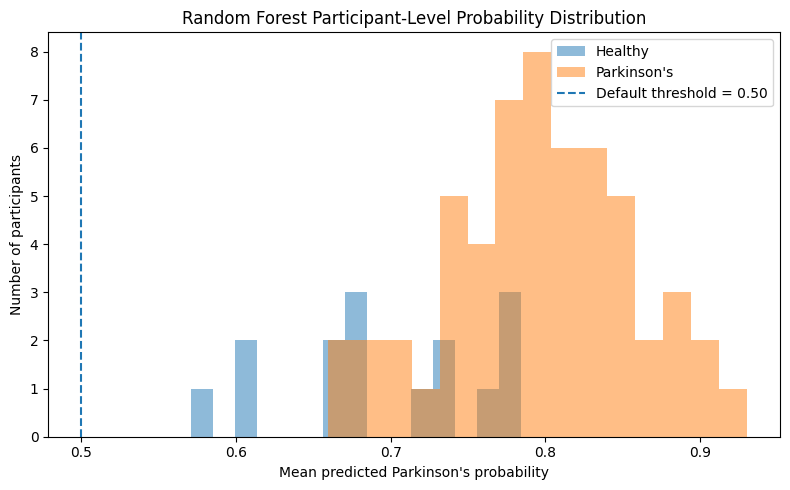

In [75]:
plt.figure(figsize=(8, 5))

for condition in ["Healthy", "Parkinson's"]:
    subset = rf_participant_predictions[
        rf_participant_predictions["condition"] == condition
    ]

    plt.hist(
        subset["mean_probability"],
        bins=15,
        alpha=0.5,
        label=condition
    )

plt.axvline(
    0.50,
    linestyle="--",
    label="Default threshold = 0.50"
)

plt.xlabel("Mean predicted Parkinson's probability")
plt.ylabel("Number of participants")
plt.title("Random Forest Participant-Level Probability Distribution")
plt.legend()
plt.tight_layout()

plt.show()

In [79]:
# Generate participant-level out-of-fold predictions
# using ONLY the training participants

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_participant_predictions = []

for fold, (fit_idx, val_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups=groups_train
    ),
    start=1
):

    fold_model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_train.iloc[fit_idx],
        y_train.iloc[fit_idx]
    )

    fold_prob = fold_model.predict_proba(
        X_train.iloc[val_idx]
    )[:, 1]

    fold_df = pd.DataFrame({
        "subject_id": groups_train.iloc[val_idx].values,
        "target": y_train.iloc[val_idx].values,
        "probability": fold_prob
    })

    # Convert recording-level probabilities
    # to participant-level probabilities
    fold_subjects = (
        fold_df
        .groupby(
            ["subject_id", "target"],
            as_index=False
        )
        .agg(
            mean_probability=("probability", "mean")
        )
    )

    oof_participant_predictions.append(fold_subjects)

    print(
        f"Fold {fold} complete - "
        f"{len(fold_subjects)} validation participants"
    )

Fold 1 complete - 57 validation participants
Fold 2 complete - 57 validation participants
Fold 3 complete - 56 validation participants
Fold 4 complete - 57 validation participants
Fold 5 complete - 57 validation participants


In [80]:
rf_oof = pd.concat(
    oof_participant_predictions,
    ignore_index=True
)

print("OOF participants:", len(rf_oof))
print("Unique participants:", rf_oof["subject_id"].nunique())

display(rf_oof.head())

OOF participants: 284
Unique participants: 284


,subject_id,target,mean_probability
0,001,0,0.727636
1,012,1,0.805273
2,022,1,0.794545
3,030,1,0.883636
4,045,0,0.720273


In [81]:
threshold_results = []

thresholds = np.arange(
    0.05,
    0.951,
    0.005
)

for threshold in thresholds:

    preds = (
        rf_oof["mean_probability"] >= threshold
    ).astype(int)

    bal_acc = balanced_accuracy_score(
        rf_oof["target"],
        preds
    )

    threshold_results.append({
        "threshold": threshold,
        "balanced_accuracy": bal_acc
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["balanced_accuracy"].idxmax()
]

best_rf_threshold = best_row["threshold"]
best_cv_balanced_accuracy = best_row["balanced_accuracy"]

print(
    f"Best RF threshold: "
    f"{best_rf_threshold:.3f}"
)

print(
    f"Training-CV balanced accuracy: "
    f"{best_cv_balanced_accuracy:.3f}"
)

Best RF threshold: 0.755
Training-CV balanced accuracy: 0.838


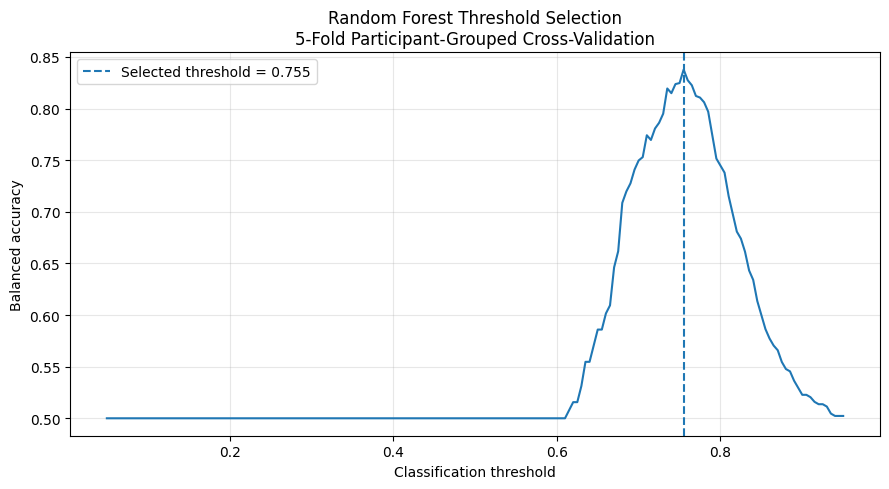

In [82]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["balanced_accuracy"]
)

plt.axvline(
    best_rf_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_rf_threshold:.3f}"
)

plt.xlabel("Classification threshold")
plt.ylabel("Balanced accuracy")
plt.title(
    "Random Forest Threshold Selection\n"
    "5-Fold Participant-Grouped Cross-Validation"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [87]:
rf_participant_predictions["prediction_tuned"] = (
    rf_participant_predictions["mean_probability"]
    >= best_rf_threshold
).astype(int)

In [89]:
rf_tuned_pred = (
    rf_participant_predictions["prediction_tuned"]
)

rf_tuned_true = (
    rf_participant_predictions["target"]
)

print("RANDOM FOREST — TRAINING-CV THRESHOLD")
print("-------------------------------------")

print(
    "Accuracy:",
    round(
        accuracy_score(
            rf_tuned_true,
            rf_tuned_pred
        ),
        3
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            rf_tuned_true,
            rf_tuned_pred
        ),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(
            rf_tuned_true,
            rf_tuned_pred
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            rf_tuned_true,
            rf_tuned_pred
        ),
        3
    )
)

print(
    "F1:",
    round(
        f1_score(
            rf_tuned_true,
            rf_tuned_pred
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            rf_participant_predictions["target"],
            rf_participant_predictions["mean_probability"]
        ),
        3
    )
)

RANDOM FOREST — TRAINING-CV THRESHOLD
-------------------------------------
Accuracy: 0.775
Balanced Accuracy: 0.76
Precision: 0.917
Recall: 0.786
F1: 0.846
ROC-AUC: 0.87


In [91]:
rf_tuned_cm = confusion_matrix(
    rf_tuned_true,
    rf_tuned_pred
)

display(
    pd.DataFrame(
        rf_tuned_cm,
        index=[
            "Actual Healthy",
            "Actual Parkinson's"
        ],
        columns=[
            "Predicted Healthy",
            "Predicted Parkinson's"
        ]
    )
)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,11,4
Actual Parkinson's,12,44


In [93]:
# Apply the LOCKED training-CV threshold to the held-out test participants

RF_THRESHOLD = best_rf_threshold

rf_participant_predictions["prediction_tuned"] = (
    rf_participant_predictions["mean_probability"] >= RF_THRESHOLD
).astype(int)

rf_test_true = rf_participant_predictions["target"]
rf_test_pred = rf_participant_predictions["prediction_tuned"]
rf_test_prob = rf_participant_predictions["mean_probability"]

In [97]:
rf_tuned_results = {
    "Model": "Random Forest (CV threshold)",
    "Accuracy": accuracy_score(rf_test_true, rf_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(
        rf_test_true, rf_test_pred
    ),
    "Precision": precision_score(
        rf_test_true, rf_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        rf_test_true, rf_test_pred
    ),
    "F1": f1_score(
        rf_test_true, rf_test_pred
    ),
    "ROC-AUC": roc_auc_score(
        rf_test_true, rf_test_prob
    )
}

print("RANDOM FOREST — LOCKED CV THRESHOLD")
print("-----------------------------------")
print(f"Threshold:          {RF_THRESHOLD:.3f}")

for metric, value in rf_tuned_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.3f}")

RANDOM FOREST — LOCKED CV THRESHOLD
-----------------------------------
Threshold:          0.755
Accuracy: 0.775
Balanced Accuracy: 0.760
Precision: 0.917
Recall: 0.786
F1: 0.846
ROC-AUC: 0.870


In [95]:
rf_tuned_cm = confusion_matrix(
    rf_test_true,
    rf_test_pred
)

rf_tuned_cm_df = pd.DataFrame(
    rf_tuned_cm,
    index=[
        "Actual Healthy",
        "Actual Parkinson's"
    ],
    columns=[
        "Predicted Healthy",
        "Predicted Parkinson's"
    ]
)

display(rf_tuned_cm_df)

,Predicted Healthy,Predicted Parkinson's
Actual Healthy,11,4
Actual Parkinson's,12,44


In [99]:
svm_auc = roc_auc_score(
    svm_participant_predictions["target"],
    svm_participant_predictions["mean_decision_score"]
)

print(f"Corrected SVM ROC-AUC: {svm_auc:.3f}")

Corrected SVM ROC-AUC: 0.881


In [101]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.761,
        "Balanced Accuracy": 0.751,
        "Precision": 0.915,
        "Recall": 0.768,
        "F1": 0.835,
        "ROC-AUC": 0.825
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(
            svm_y_true, svm_y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            svm_y_true, svm_y_pred
        ),
        "Precision": precision_score(
            svm_y_true, svm_y_pred
        ),
        "Recall": recall_score(
            svm_y_true, svm_y_pred
        ),
        "F1": f1_score(
            svm_y_true, svm_y_pred
        ),
        "ROC-AUC": svm_auc
    },
    rf_tuned_results
])

display(
    model_comparison
    .set_index("Model")
    .round(3)
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Logistic Regression,0.761,0.751,0.915,0.768,0.835,0.825
SVM,0.732,0.757,0.930,0.714,0.808,0.881
Random Forest (CV threshold),0.775,0.760,0.917,0.786,0.846,0.870


In [103]:
OUTPUT_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.to_csv(
    OUTPUT_DIR / "model_comparison_holdout.csv",
    index=False
)